In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.api as sms

# Завантаження та первинна обробка даних

In [ ]:
# 1. Upload the file
df = pd.read_csv('food detector split.csv')
df.head()

,user_id,country,language,device_type,event_type,split_group,event_properties__answer,event_time,session_id
0,B471DDBC-BFA8-415D-866F-CD9AA417E200,United States,English,Apple iPhone 15 Pro Max,launch_first_time,control,NaN,2025-09-11 19:57:20.265000,1757620638294
1,5167F324-660D-4891-A14E-DB096679A081,Germany,German,Apple iPhone SE (3rd generation),Purchase,control,NaN,2025-09-29 03:39:11.124000,-1
2,92386D0A-B05A-4768-BC76-275D1EE2178C,United States,English,Apple iPhone 16,launch_first_time,test,NaN,2025-09-29 03:37:18.849000,1759117037805
3,144D9ACC-498F-4BB4-B7E5-9145E0A1BBE9,Brazil,Portuguese,Apple iPhone 14 Pro Max,Purchase,test,NaN,2025-09-29 03:21:09.456000,-1
4,4E5658C4-E9E2-4676-B8E0-DA35F875E9FE,United States,English,Apple iPhone 14,Purchase,test,NaN,2025-09-29 03:51:19.721000,-1


In [ ]:
# Datetime type change
df['event_time'] = pd.to_datetime(df['event_time'])

In [ ]:
# 2. Формування датасету Customers
# Сортуємо дані за часом, щоб .first() завжди брав ранню подію
df_sorted = df.sort_values(['user_id', 'event_time'])

In [ ]:
# Створюємо допоміжні мітки для агрегації умов (like/dislike)
df_sorted['is_like'] = (df_sorted['event_type'] == 'identification_results_reaction_sent') & (df_sorted['event_properties__answer'] == 'like')
df_sorted['is_dislike'] = (df_sorted['event_type'] == 'identification_results_reaction_sent') & (df_sorted['event_properties__answer'] == 'dislike')


# Агрегація даних на рівні user_id

In [ ]:
customers = df_sorted.groupby('user_id').agg(
   # Агрегація категоріальних полів (перше значення за часом)
    device_type=('device_type', 'first'),
    language=('language', 'first'),
    country=('country', 'first'),
    split_group=('split_group', 'first'),

    # Логічні колонки (наявність події в історії користувача)
    launch_first_time=('event_type', lambda x: 1 if (x == 'launch_first_time').any() else 0),
    start_trial=('event_type', lambda x: 1 if (x == 'Start trial').any() else 0),
    purchase=('event_type', lambda x: 1 if (x == 'Purchase').any() else 0),

    # Умови щодо полів лайків
    like=('is_like', lambda x: 1 if x.any() else 0),
    dislike=('is_dislike', lambda x: 1 if x.any() else 0),

    likes_count=('is_like', 'sum'),
    dislikes_count=('is_dislike', 'sum'),

    # Дати
    date_start=('event_time', lambda x: x.min().date()),
    date_end=('event_time', lambda x: x.max().date())
).reset_index()

In [ ]:
# Вивід результату
print("Сформований датасет Customers:")

Сформований датасет Customers:


In [ ]:
customers

,user_id,device_type,language,country,split_group,launch_first_time,start_trial,purchase,like,dislike,likes_count,dislikes_count,date_start,date_end
0,00008C8A-40EA-4501-B16F-503D5210938A,Apple iPhone 14 Plus,English,United States,test,1,0,0,0,0,0,0,2025-09-15,2025-09-15
1,0000BB87-F3B6-4DF4-86CC-2D51C52E3381,Apple iPhone 15 Pro Max,English,United States,test,1,0,0,0,0,0,0,2025-09-19,2025-09-19
2,0001685E-775E-493E-82F5-ECBD2886669B,Apple iPhone 16 Pro Max,English,United States,test,1,0,0,0,0,0,0,2025-09-10,2025-09-10
3,000386AD-8313-47A1-91AE-EECE663CAFD7,Apple iPhone 13 Pro Max,English,United States,control,1,0,0,0,0,0,0,2025-09-13,2025-09-13
4,0007948B-B775-4B9A-A481-0B9F36F7BD99,Apple iPhone SE (3rd generation),English,United States,test,1,0,0,0,0,0,0,2025-09-18,2025-09-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48758,FFFC17EC-6CC0-48EC-AF96-A9C941384B6C,Apple iPhone 11,English,United Kingdom,test,1,0,0,0,0,0,0,2025-08-14,2025-08-14
48759,FFFC77B9-B840-4E94-B2B1-A689EB85A63E,Apple iPhone 14,English,United States,test,1,0,0,0,0,0,0,2025-09-27,2025-09-27
48760,FFFD676F-D494-4E15-84B8-A1E113AE7010,Apple iPhone 13 Pro Max,Portuguese,Brazil,test,1,0,0,0,0,0,0,2025-09-10,2025-09-10
48761,FFFE2726-B369-486E-80B6-64B67B1C67DE,Apple iPhone XS,English,United Kingdom,test,1,0,0,0,0,0,0,2025-09-14,2025-09-16


# Аналіз CR та розміру вибірки

In [ ]:
# 2. Базова інформація по групам
summary = customers.groupby('split_group').agg(
    users=('user_id', 'count'),
    conversions=('purchase', 'sum')
)
summary['cr'] = summary['conversions'] / summary['users']
print("Зведення по групам:")
print(summary)

Зведення по групам:
             users  conversions        cr
split_group                              
control      24296         2456  0.101087
test         24467         2625  0.107287


In [ ]:
alpha = 0.05
power = 0.8

In [ ]:
from statsmodels.stats.power import NormalIndPower
import statsmodels.stats.proportion as prop

# Переводимо конверсії у стандартизований ефект effect_size (h Коена)
cr_Control = summary.loc['control', 'cr']
cr_Test = summary.loc['test', 'cr']
effect_size = prop.proportion_effectsize(cr_Test, cr_Control)

# Рахуємо розмір вибірки
analysis = NormalIndPower()
n_required = analysis.solve_power(effect_size=effect_size, nobs1=None, alpha=alpha, power=power, ratio=1.0)

print(f"Потрібно спостережень у КОЖНІЙ групі: {round(n_required)} при alpha={alpha}, power={power}, cr_Control= {round(cr_Control,4)}, cr_Test= {round(cr_Test,4)} ")

Потрібно спостережень у КОЖНІЙ групі: 38097 при alpha=0.05, power=0.8, cr_Control= 0.1011, cr_Test= 0.1073 


In [ ]:
# Поточні параметри
n_total = summary['users'].sum() / 2  # Середнє на одну групу

# Розрахунок досяжного MDE
analysis = sms.NormalIndPower()
attained_effect = analysis.solve_power(effect_size=None, nobs1=n_total, alpha=alpha, power=power, ratio=1.0)
p2 = np.sin(attained_effect/2 + np.arcsin(np.sqrt(cr_Control)))**2
min_attained_mde = p2 - cr_Control

print(f"CR Control: {cr_Control:.2%}")
print(f"З поточним обсягом трафіку ми могли б помітити ефект min приблизно в {min_attained_mde*100:.1f} процентних пункта.")

CR Control: 10.11%
З поточним обсягом трафіку ми могли б помітити ефект min приблизно в 0.8 процентних пункта.


In [ ]:
achieved_power = analysis.solve_power(effect_size=effect_size, nobs1=n_total, alpha=alpha, power=None, ratio=1.0)
print(f"Поточна потужність теста: {achieved_power:.1%}")

Поточна потужність теста: 61.1%


# Аналіз CR по language

In [ ]:
from scipy.stats import norm

def calculate_ab_metrics(df):
    results = []

    # Группування по language
    for lang, group in df.groupby('language'):
        # Розділяємо на групи
        ctrl = group[group['split_group'] == 'control']
        test = group[group['split_group'] == 'test']

        # 1. Розмір груп
        n_ctrl = len(ctrl)
        n_test = len(test)

        if n_ctrl == 0 or n_test == 0:
            continue

        # 2. Конверсія (на основі колонки purchase)
        p_ctrl = ctrl['purchase'].mean()
        p_test = test['purchase'].mean()

        # 3. Приріст (Lift)
        abs_lift = p_test - p_ctrl
        rel_lift = (p_test / p_ctrl - 1) if p_ctrl > 0 else 0

        # 4. Розрахунок потужності (Power)
        # Використовуємо формулу Z-теста
        z_alpha = norm.ppf(1 - alpha / 2)

        p_avg = (p_ctrl + p_test) / 2
        # Уникаємо ділення на нуль за відсутності конверсій
        if 0 < p_avg < 1:
            se = np.sqrt(p_avg * (1 - p_avg) * (1/n_ctrl + 1/n_test))
            z_beta = (abs(abs_lift) / se) - z_alpha
            power = norm.cdf(z_beta)
        else:
            power = 0

        results.append({
            'Language': lang,
            'N Control': n_ctrl,
            'N Test': n_test,
            'CR Control': f"{p_ctrl:.2%}",
            'CR Test': f"{p_test:.2%}",
            'Abs Lift': f"{abs_lift:+.4f}",
            'Rel Lift': f"{rel_lift:+.2%}",
            'Power': f"{power:.2%}"
        })

    return pd.DataFrame(results)

In [ ]:
# Запуск анализу
lang_stats = calculate_ab_metrics(customers)
lang_stats = lang_stats.sort_values(['N Control'], ascending=False)
display(lang_stats)

,Language,N Control,N Test,CR Control,CR Test,Abs Lift,Rel Lift,Power
10,English,17273,17531,11.78%,12.55%,+0.0077,+6.57%,59.78%
28,Portuguese,2663,2630,7.55%,6.88%,-0.0067,-8.82%,15.29%
12,French,1306,1303,3.14%,4.37%,+0.0124,+39.34%,38.17%
19,Italian,839,841,3.69%,4.76%,+0.0106,+28.73%,18.98%
34,Spanish,571,644,12.08%,11.18%,-0.0090,-7.48%,7.09%
9,Dutch,411,397,3.16%,3.78%,+0.0062,+19.45%,6.91%
13,German,350,308,7.71%,3.90%,-0.0382,-49.49%,55.17%
8,Danish,167,167,4.19%,9.58%,+0.0539,+128.57%,49.39%
35,Swedish,124,124,3.23%,5.65%,+0.0242,+75.00%,15.04%
30,Russian,80,72,2.50%,0.00%,-0.0250,-100.00%,28.27%


# # Аналіз p-value по language

In [ ]:
from scipy.stats import fisher_exact, norm
from statsmodels.stats.proportion import proportions_ztest

def analyze_languages_comprehensive(df):
    analysis_results = []

    # Групування по мові користувача
    for lang, group in df.groupby('language'):
        # Розбиваємо на групи по split_group
        ctrl = group[group['split_group'] == 'control']
        test = group[group['split_group'] == 'test']

        n_ctrl, x_ctrl = len(ctrl), ctrl['purchase'].sum()
        n_test, x_test = len(test), test['purchase'].sum()

        # Пропускаємо, якщо в одній из груп немає даних
        if n_ctrl == 0 or n_test == 0:
            continue

        # 1. Метрики конверсії (CR)
        cr_ctrl = x_ctrl / n_ctrl
        cr_test = x_test / n_test
        lift = (cr_test / cr_ctrl - 1) if cr_ctrl > 0 else 0

        # 2. Z-тест (параметричний метод)
        z_stat, p_val_z = proportions_ztest([x_test, x_ctrl], [n_test, n_ctrl])

        # 3. Точний тест Фішера (непараметричний)
        # Підходить для малих выбірок
        # Складаємо таблицю сполученості: [[успіхи_test, невдачі_test], [успіхи_ctrl, невдачі_ctrl]]
        table = [[x_test, n_test - x_test], [x_ctrl, n_ctrl - x_ctrl]]
        _, p_val_fisher = fisher_exact(table)

        # 4. Розрахунок потужності (Power)
        z_alpha = norm.ppf(1 - alpha / 2)
        p_pooled = (x_ctrl + x_test) / (n_ctrl + n_test)
        if 0 < p_pooled < 1:
            se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ctrl + 1/n_test))
            power = norm.cdf((abs(cr_test - cr_ctrl) / se) - z_alpha)
        else:
            power = 0

        analysis_results.append({
            'Language': lang,
            'Users': n_ctrl+n_test,
            'Users (C/T)': f"{n_ctrl} / {n_test}",
            'Purchases (C/T)': f"{int(x_ctrl)} / {int(x_test)}",
            'CR Control': f"{cr_ctrl:.2%}",
            'CR Test': f"{cr_test:.2%}",
            'Rel. Lift': f"{lift:+.2%}",
            'P-Value (Z-test)': round(p_val_z, 4),
            'P-Value (Fisher)': round(p_val_fisher, 4),
            'Power': f"{power:.2%}",
            'Significant': 'Yes' if p_val_z < alpha else 'No'
        })

    return pd.DataFrame(analysis_results).sort_values(['Users'], ascending=False)

In [ ]:
# Застосовуємо функцію до датасету
lang_report = analyze_languages_comprehensive(customers)
display(lang_report)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,Language,Users,Users (C/T),Purchases (C/T),CR Control,CR Test,Rel. Lift,P-Value (Z-test),P-Value (Fisher),Power,Significant
10,English,34804,17273 / 17531,2034 / 2200,11.78%,12.55%,+6.57%,0.0273,0.0280,59.77%,Yes
28,Portuguese,5293,2663 / 2630,201 / 181,7.55%,6.88%,-8.82%,0.3493,0.3666,15.29%,No
12,French,2609,1306 / 1303,41 / 57,3.14%,4.37%,+39.34%,0.0971,0.1004,38.18%,No
19,Italian,1680,839 / 841,31 / 40,3.69%,4.76%,+28.73%,0.2796,0.3320,18.98%,No
34,Spanish,1215,571 / 644,69 / 72,12.08%,11.18%,-7.48%,0.6234,0.6541,7.09%,No
9,Dutch,808,411 / 397,13 / 15,3.16%,3.78%,+19.45%,0.6326,0.7024,6.92%,No
13,German,658,350 / 308,27 / 12,7.71%,3.90%,-49.49%,0.0385,0.0465,54.37%,Yes
8,Danish,334,167 / 167,7 / 16,4.19%,9.58%,+128.57%,0.0518,0.0819,49.39%,No
35,Swedish,248,124 / 124,4 / 7,3.23%,5.65%,+75.00%,0.3548,0.5395,15.04%,No
30,Russian,152,80 / 72,2 / 0,2.50%,0.00%,-100.00%,0.1768,0.4981,27.11%,No


In [ ]:
lang_report.to_csv('lang_report.csv', index=False)

# Аналіз Likes/Dislikes

In [ ]:
from scipy.stats import mannwhitneyu

def analyze_interactions_mann_whitney(df):
    results = []

    # Групування по мові
    for lang, group in df.groupby('language'):
        # Розділення на тестову и контрольну групи
        ctrl = group[group['split_group'] == 'control']
        test = group[group['split_group'] == 'test']

        # Перевіряємо наявність даних в обох групах
        if len(ctrl) < 5 or len(test) < 5:
            continue  # Пропускаємо  - замала выбірка для надійності

        # 1. Тест для лайків
        stat_likes, p_val_likes = mannwhitneyu(
            test['likes_count'],
            ctrl['likes_count'],
            alternative='two-sided'
        )

        # 2. Тест для дизлайків
        stat_dislikes, p_val_dislikes = mannwhitneyu(
            test['dislikes_count'],
            ctrl['dislikes_count'],
            alternative='two-sided'
        )

        results.append({
            'Language': lang,
            'Users': len(ctrl)+len(test),
            'Users (C/T)': f"{len(ctrl)} / {len(test)}",
            'Avg Likes (C/T)': f"{ctrl['likes_count'].mean():.2f} / {test['likes_count'].mean():.2f}",
            'P-Value Likes': round(p_val_likes, 4),
            'Avg Dislikes (C/T)': f"{ctrl['dislikes_count'].mean():.2f} / {test['dislikes_count'].mean():.2f}",
            'P-Value Dislikes': round(p_val_dislikes, 4),
            'Significant Likes': 'Yes' if p_val_likes < alpha else 'No',
            'Significant Dislikes': 'Yes' if p_val_dislikes < alpha else 'No'
        })

    return pd.DataFrame(results).sort_values(['Users'], ascending=False)

In [ ]:
# Застосовуємо функцію до датасету customers
mw_report = analyze_interactions_mann_whitney(customers)
display(mw_report)

,Language,Users,Users (C/T),Avg Likes (C/T),P-Value Likes,Avg Dislikes (C/T),P-Value Dislikes,Significant Likes,Significant Dislikes
6,English,34804,17273 / 17531,0.29 / 0.27,0.0964,0.13 / 0.11,0.0003,No,Yes
18,Portuguese,5293,2663 / 2630,0.17 / 0.17,0.7298,0.08 / 0.09,0.9938,No,No
8,French,2609,1306 / 1303,0.10 / 0.12,0.3731,0.04 / 0.05,0.6472,No,No
14,Italian,1680,839 / 841,0.17 / 0.23,0.3454,0.05 / 0.04,0.1379,No,No
21,Spanish,1215,571 / 644,0.34 / 0.19,0.7086,0.12 / 0.08,0.0596,No,No
5,Dutch,808,411 / 397,0.06 / 0.13,0.0397,0.03 / 0.03,0.3866,Yes,No
9,German,658,350 / 308,0.22 / 0.16,0.0122,0.04 / 0.05,0.8540,Yes,No
4,Danish,334,167 / 167,0.07 / 0.14,0.3565,0.04 / 0.04,0.3183,No,No
22,Swedish,248,124 / 124,0.13 / 0.15,0.8203,0.03 / 0.02,0.9903,No,No
20,Russian,152,80 / 72,0.05 / 0.07,0.8429,0.03 / 0.00,0.1813,No,No


In [ ]:
mw_report.to_csv('mw_report.csv', index=False)

# Аналіз розподілу

Конверсія

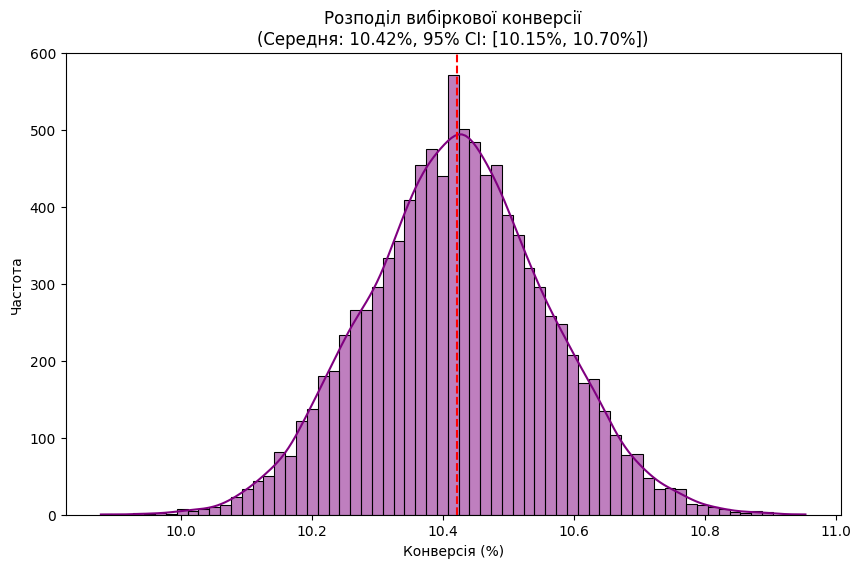

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Параметри
n_iterations = 10000
conversion_means = []

# 2. Бутстреп (цикл для генерації вибіркових середніх)
for i in range(n_iterations):
    # Вибираємо випадкових користувачів із поверненням (frac=1 означає розмір всієї вибірки)
    sample = customers['purchase'].sample(frac=1, replace=True)

    # Середнє бінарної колонки [0, 1, 0...] — це і є конверсія (наприклад, 0.05 для 5%)
    conversion_means.append(sample.mean())

# 3. Візуалізація
plt.figure(figsize=(10, 6))
# Помножимо на 100, щоб бачити результат у відсотках
sns.histplot([m * 100 for m in conversion_means], kde=True, color='purple')

# Розрахунок довірчого інтервалу (2.5% та 97.5% квантилі)
ci_low = np.percentile(conversion_means, 2.5) * 100
ci_high = np.percentile(conversion_means, 97.5) * 100
mean_val = np.mean(conversion_means) * 100

plt.title(f'Розподіл вибіркової конверсії\n(Середня: {mean_val:.2f}%, 95% CI: [{ci_low:.2f}%, {ci_high:.2f}%])')
plt.xlabel('Конверсія (%)')
plt.ylabel('Частота')
plt.axvline(mean_val, color='red', linestyle='--')
plt.show()

Лайки

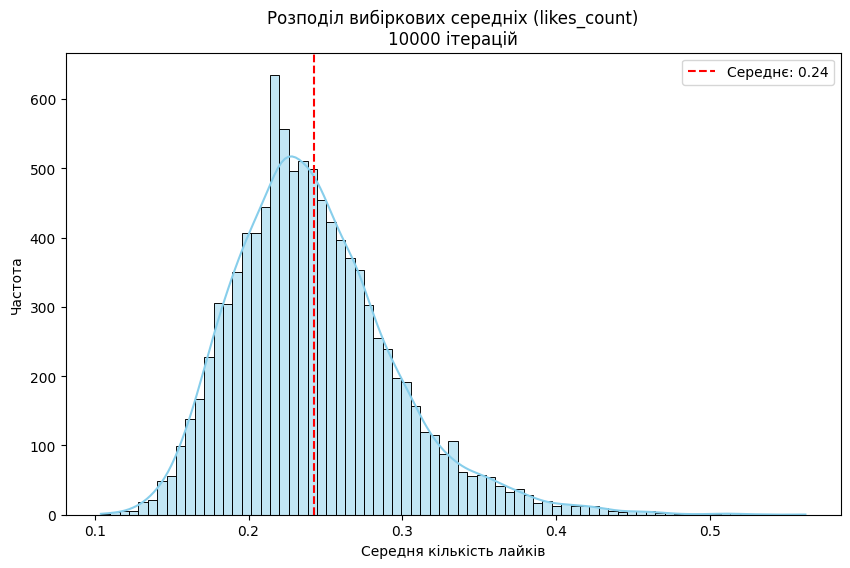

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Налаштування параметрів
n_iterations = 10000  # Кількість вибірок (ітерацій)
sample_size = 500     # Розмір кожної вибірки (можна взяти len(customers))
means = []

# 2. Процес бутстрепу
# Ми беремо випадкові підмножини з заміною (replace=True)
for i in range(n_iterations):
    sample = customers['likes_count'].sample(n=sample_size, replace=True)
    means.append(sample.mean())

# 3. Візуалізація
plt.figure(figsize=(10, 6))
sns.histplot(means, kde=True, color='skyblue')
plt.title(f'Розподіл вибіркових середніх (likes_count)\n{n_iterations} ітерацій')
plt.xlabel('Середня кількість лайків')
plt.ylabel('Частота')

# Додамо лінії для наочності
plt.axvline(np.mean(means), color='red', linestyle='--', label=f'Середнє: {np.mean(means):.2f}')
plt.legend()
plt.show()